In [ ]:
import pandas as pd
import numpy as np
import optuna
from optuna.samplers import TPESampler
import lightgbm as lgb
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import warnings

In [ ]:
# ==========================================
# 1. 원천(Raw) 데이터 로드 (기존 병합본 폐기)
# ==========================================
info_df = pd.read_csv('/Users/kwagminseo/Documents/SAS/data/train/train_customer_info.csv')
finance_df = pd.read_csv('/Users/kwagminseo/Documents/SAS/data/train/train_finance_profile.csv')
trans_df = pd.read_csv('/Users/kwagminseo/Documents/SAS/data/train/train_transaction_history.csv')
targets_df = pd.read_csv('/Users/kwagminseo/Documents/SAS/data/train/train_targets.csv')

In [ ]:
# 2. RFM 지표 추출 (transaction_history 기준)
trans_df['trans_date'] = pd.to_datetime(trans_df['trans_date'])
base_date = pd.to_datetime('2023-12-31')

rfm_df = trans_df.groupby('customer_id').agg(
    Recency=('trans_date', lambda x: (base_date - x.max()).days),
    Frequency=('trans_id', 'count'),
    Monetary=('trans_amount', 'sum')
).reset_index()

In [ ]:
# 3. 금융 위험 지표 이진화 및 총 부채액 합산 (finance_profile 기준)
finance_df['has_overdue'] = (finance_df['fin_overdue_days'] > 0).astype(int)
finance_df['has_cash_svc'] = (finance_df['card_cash_service_amt'] > 0).astype(int)
finance_df['has_card_loan'] = (finance_df['card_loan_amt'] > 0).astype(int)
finance_df['total_debt'] = finance_df['card_cash_service_amt'] + finance_df['card_loan_amt'] + finance_df['total_loan_balance']

In [ ]:
# 4. 자산 변동 추세 구간화 (이탈 위험 가중치 반영)
# -3(급감)에 가까울수록 위험군(가장 높은 가중치 3), +3에 가까울수록 안정군(0)
bins = [-np.inf, -2, 0, 2, np.inf]
labels = [3, 2, 1, 0]  # 위험도(Risk Level): 3이 가장 위험
finance_df['asset_trend_risk'] = pd.cut(finance_df['fin_asset_trend_score'], bins=bins, labels=labels).astype(int)

In [ ]:
# 5. 데이터 병합 (Merge)
df = info_df.merge(rfm_df, on='customer_id', how='left')
df = df.merge(finance_df, on='customer_id', how='left')
df = df.merge(targets_df, on='customer_id', how='inner')

In [ ]:
print("SMOTE 적용을 위해 문자열 및 날짜 데이터를 숫자형으로 변환합니다...")

# 1. 날짜형 데이터(join_date) 처리: 가입일수(tenure_days)로 변환 후 원본 날짜 삭제
if 'join_date' in df.columns:
    df['join_date'] = pd.to_datetime(df['join_date'])
    base_date = pd.to_datetime('2023-12-31')
    df['tenure_days'] = (base_date - df['join_date']).dt.days
    df.drop(columns=['join_date'], inplace=True) # 🚨 SMOTE가 싫어하는 원본 날짜 삭제

In [ ]:
# ==============================================================================
# [STEP 2] 데이터 누수 방지: Train / Valid 분할
# ==============================================================================
print("데이터를 분할하고 SMOTE 및 모델 튜닝을 준비합니다...")

features = [col for col in df.columns if col not in ['customer_id', 'target_churn', 'target_ltv']]
X = df[features]
y = df['target_churn']

# Stratify를 적용하여 타겟 클래스 불균형 비율 유지
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
print("▶️ SMOTE를 위해 모든 문자열/카테고리 데이터를 숫자로 강제 변환합니다...")

# 1. 분할 전 전체 데이터프레임(df)에서 글자나 카테고리로 된 컬럼만 자동으로 싹 다 찾기
cat_cols = df.select_dtypes(include=['object', 'category']).columns
print(f"변환 대상 컬럼: {list(cat_cols)}")

# 2. 찾은 컬럼들을 하나씩 돌면서 Label Encoding (예: 'F'->0, 'M'->1) 진행
for col in cat_cols:
    le = LabelEncoder()
    # 결측치나 이상한 타입이 섞여 있을 수 있으니 전부 강제로 문자열 취급(astype(str)) 후 숫자로 변환
    df[col] = le.fit_transform(df[col].astype(str))

print("✅ 모든 글자 데이터가 숫자로 변환되었습니다!\n")

# ==========================================
# 이후 여기서부터 다시 X, y 나누고 학습 시작!
# ==========================================
# (이전에 작성하셨던 X, y 분할 코드 및 Optuna 코드를 이 아래에 두고 다시 실행하시면 됩니다.)
features = [col for col in df.columns if col not in ['customer_id', 'target_churn', 'target_ltv']]
X = df[features]
y = df['target_churn']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
def objective(trial):
    # Search Space
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'num_leaves': trial.suggest_int('num_leaves', 10, 100),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
        'class_weight': 'balanced', # 트리 내부적으로도 불균형 고려
        'random_state': 42,
        'n_jobs': -1
    }
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    auc_scores = []
    
    for train_idx, val_idx in cv.split(X_train, y_train):
        # CV 내부에서 Train / Validation Fold 분할
        X_fold_train, y_fold_train = X_train.iloc[train_idx], y_train.iloc[train_idx]
        X_fold_valid, y_fold_valid = X_train.iloc[val_idx], y_train.iloc[val_idx]
        
        # 🚨 [데이터 누수 방지 핵심] 훈련 폴드에만 SMOTE 적용
        smote = SMOTE(random_state=42)
        X_fold_train_smote, y_fold_train_smote = smote.fit_resample(X_fold_train, y_fold_train)
        
        # 모델 학습
        model = lgb.LGBMClassifier(**param)
        model.fit(X_fold_train_smote, y_fold_train_smote)
        
        # 검증 (Probability 기반)
        preds = model.predict_proba(X_fold_valid)[:, 1]
        auc = roc_auc_score(y_fold_valid, preds)
        auc_scores.append(auc)
        
    return np.mean(auc_scores)

# ROC-AUC를 '최대화(maximize)' 하는 방향으로 Optuna 설정
study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
print("Optuna 하이퍼파라미터 탐색을 시작합니다...")
study.optimize(objective, n_trials=30)  # 대회 시간에 맞춰 n_trials 조정

print(f"Best Trial: {study.best_trial.value}")
print(f"Best Params: {study.best_params}")

In [13]:
# ==============================================================================
# [STEP 4] 최적 모델 재학습 및 최종 제출 파일(Submission) 도출
# ==============================================================================
# 찾아낸 베스트 파라미터로 전체 Train 데이터에 대해 학습 진행
best_params = study.best_params
best_params['class_weight'] = 'balanced'
best_params['random_state'] = 42

# Train 전체 데이터에도 SMOTE 적용
final_smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = final_smote.fit_resample(X_train, y_train)

final_model = lgb.LGBMClassifier(**best_params)
final_model.fit(X_train_smote, y_train_smote)

# 검증셋 평가
valid_preds = final_model.predict_proba(X_val)[:, 1]
final_auc = roc_auc_score(y_valid, valid_preds)
print(f"최종 Validation ROC-AUC Score: {final_auc:.4f}")

[LightGBM] [Info] Number of positive: 43257, number of negative: 43257
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002226 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2512
[LightGBM] [Info] Number of data points in the train set: 86514, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
최종 Validation ROC-AUC Score: 0.7345


🔍 최종 모델 예측 결과 정밀 분석을 시작합니다...

🚨 [분석 필수] 모델이 완벽하게 속아넘어간 워스트 케이스 Top 10
-> 실제 이탈(1)인데 확률이 0.01이거나, 유지(0)인데 0.99로 예측한 치명적 오답들입니다.


,Actual_Churn,Predicted_Prob,Error_Gap,age,gender,region_code,is_married,prefer_category
36160,0,0.901178,0.901178,38,F,R02,0,Grocery
30697,0,0.891031,0.891031,25,F,R01,0,Beauty
51603,0,0.890656,0.890656,41,F,R01,0,Beauty
26492,0,0.889993,0.889993,42,F,R06,0,Electronics
20642,0,0.885937,0.885937,44,F,R06,1,Electronics
3528,0,0.885784,0.885784,42,F,R03,1,Electronics
4181,0,0.883250,0.883250,22,F,R05,0,Electronics
47228,1,0.124027,0.875973,19,M,R05,1,Fashion
42574,1,0.124520,0.875480,37,M,R01,1,Electronics
43760,1,0.125579,0.874421,23,M,R05,1,Home


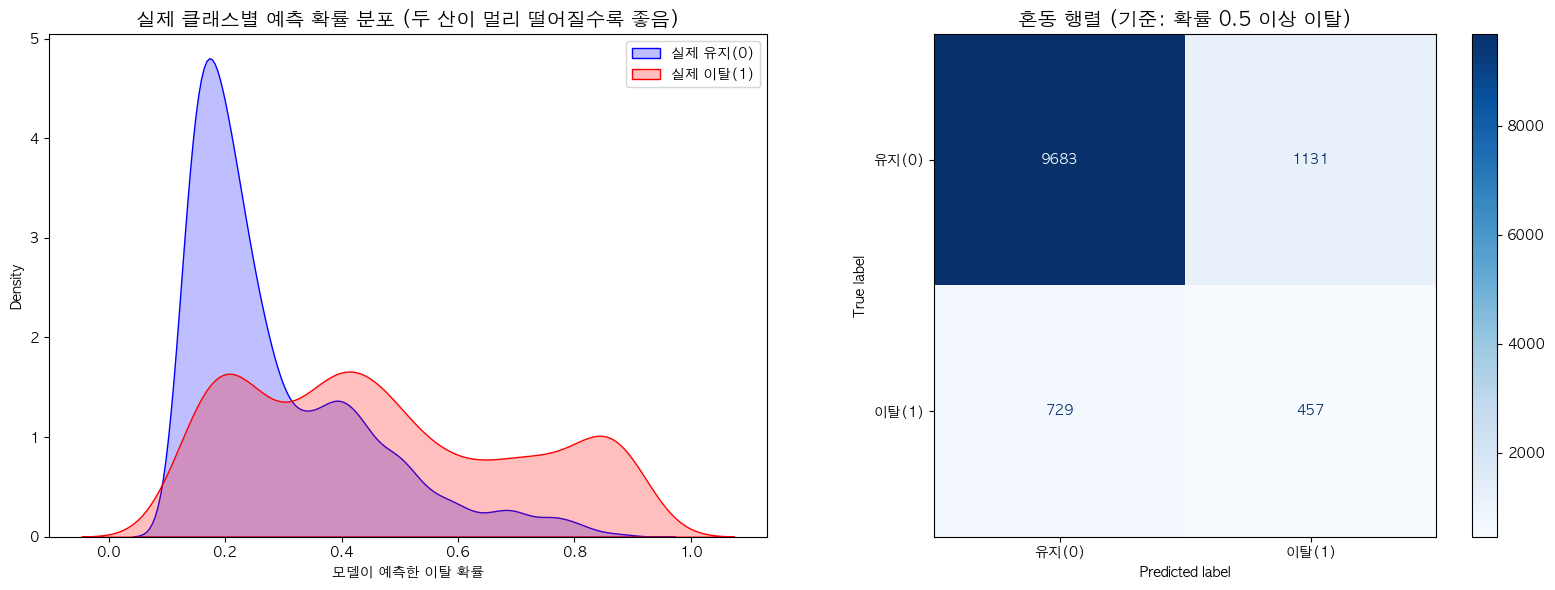

/var/folders/9v/y1lmnflj4ws9l3cby1188f400000gn/T/ipykernel_83922/542556615.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp.head(10), palette='Reds_r')
/opt/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


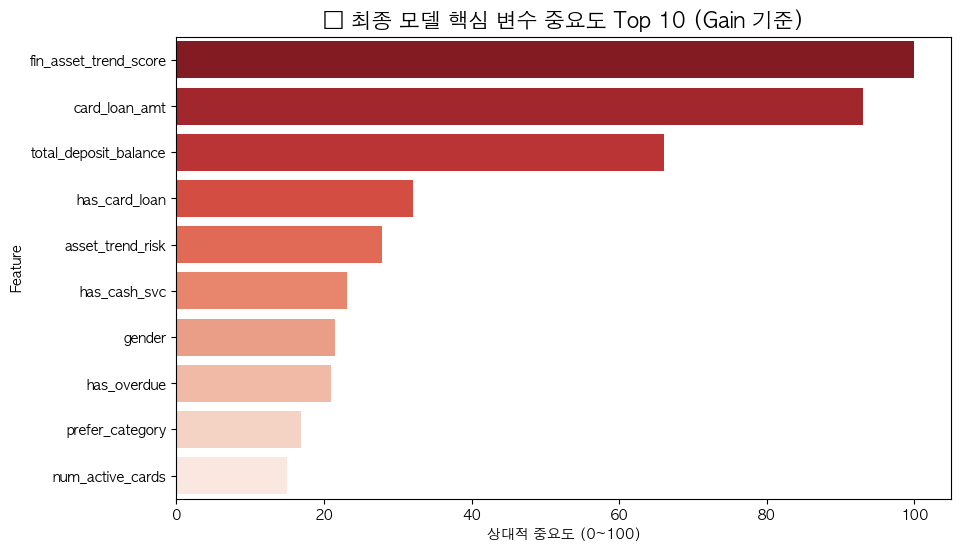

In [16]:
print("🔍 최종 모델 예측 결과 정밀 분석을 시작합니다...\n")

# 한글 폰트 깨짐 방지 (맥OS는 'AppleGothic', 윈도우는 'Malgun Gothic' 사용)
plt.rcParams['font.family'] = 'AppleGothic' # 윈도우라면 'Malgun Gothic'으로 변경!
plt.rcParams['axes.unicode_minus'] = False

# ==============================================================================
# 1. 눈으로 직접 확인하는 예측 결과 데이터프레임 만들기
# ==============================================================================
# 검증 데이터(X_valid)에 실제 정답과 예측 확률을 붙입니다.
results_df = X_valid.copy()
results_df['Actual_Churn'] = y_valid
results_df['Predicted_Prob'] = valid_preds

# 예측 오차(Error) 계산: 1에 가까울수록 모델이 완벽하게 헛짚었다는 뜻
results_df['Error_Gap'] = abs(results_df['Actual_Churn'] - results_df['Predicted_Prob'])

print("🚨 [분석 필수] 모델이 완벽하게 속아넘어간 워스트 케이스 Top 10")
print("-> 실제 이탈(1)인데 확률이 0.01이거나, 유지(0)인데 0.99로 예측한 치명적 오답들입니다.")
worst_cases = results_df.sort_values(by='Error_Gap', ascending=False).head(10)
display(worst_cases[['Actual_Churn', 'Predicted_Prob', 'Error_Gap'] + features[:5]]) # 앞부분 피처만 살짝 보기

# ==============================================================================
# 2. 오차 분석 시각화 (예측 확률 분포도)
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# [그래프 1] 클래스별 예측 확률 분포 (Density Plot)
sns.kdeplot(data=results_df[results_df['Actual_Churn']==0], x='Predicted_Prob', fill=True, color='blue', label='실제 유지(0)', ax=axes[0])
sns.kdeplot(data=results_df[results_df['Actual_Churn']==1], x='Predicted_Prob', fill=True, color='red', label='실제 이탈(1)', ax=axes[0])
axes[0].set_title('실제 클래스별 예측 확률 분포 (두 산이 멀리 떨어질수록 좋음)', fontsize=14)
axes[0].set_xlabel('모델이 예측한 이탈 확률')
axes[0].legend()

# [그래프 2] 혼동 행렬 (임계값 0.5 기준)
THRESHOLD = 0.5
predicted_class = (valid_preds >= THRESHOLD).astype(int)
cm = confusion_matrix(y_valid, predicted_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['유지(0)', '이탈(1)'])
disp.plot(cmap='Blues', ax=axes[1], values_format='d')
axes[1].set_title(f'혼동 행렬 (기준: 확률 {THRESHOLD} 이상 이탈)', fontsize=14)

plt.tight_layout()
plt.show()

# ==============================================================================
# 3. 최종 모델의 피처 중요도 (Gain 기준)
# ==============================================================================
# SMOTE와 Optuna를 거친 최종 모델은 과연 어떤 변수를 보고 판단했을까?
feature_imp = pd.DataFrame({
    'Feature': features,
    'Importance': final_model.booster_.feature_importance(importance_type='gain')
})

# 100점 만점으로 스케일링
feature_imp['Importance'] = 100 * (feature_imp['Importance'] / feature_imp['Importance'].max())
feature_imp = feature_imp.sort_values(by='Importance', ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp.head(10), palette='Reds_r')
plt.title('🔥 최종 모델 핵심 변수 중요도 Top 10 (Gain 기준)', fontsize=15)
plt.xlabel('상대적 중요도 (0~100)')
plt.show()